## Assignment 3:  Data Visualization & Linear Regression

#### Scatterplots, Faceting, Distribution & Categorical Plots,  
####Linear Regression  for inference & Prediction

In [106]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import statsmodels.formula.api as smf
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

df = pd.read_csv(
    "https://raw.githubusercontent.com/Reben80/Data201/refs/heads/main/Dataset/housing.csv")
pd.options.display.float_format = '{:.2f}'.format
df.head()

,listing_id,price,size,bedrooms,neighborhood,type
0,100001,145143.00,1280.74,1.00,Suburb,Townhouse
1,100002,152251.00,1406.28,2.00,Uptown,SingleFamily
2,100003,148251.00,4146.83,6.00,Suburb,MultiFamily
3,100004,177711.00,3946.60,6.00,Suburb,SingleFamily
4,100005,155269.00,1243.75,1.00,Downtown,MultiFamily


### Part I:  Visualization
#### A. Scatterplots and Aesthetics
1.  Create a scatterplot of **size vs price**.

    -   Label axes clearly.
    -   Add a meaningful title.

2.  Recreate the plot using `color = neighborhood` (use seaborn).

3.  Use transparency (`alpha`) to reduce overplotting.

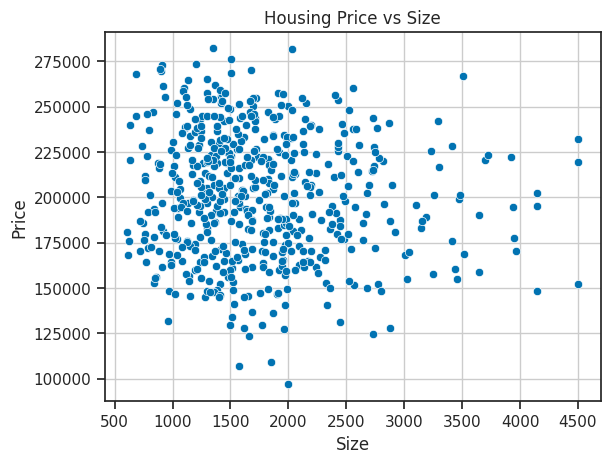

In [24]:
#print(plt.style.available)
sns.set_theme(style = "ticks", palette = "colorblind")  # palette = "colorblind"
# ticks shows grid

sns.scatterplot(data = df, x = "size", y = "price")  # shows grid
plt.xlabel("Size")
plt.ylabel("Price")
plt.title("Housing Price vs Size")
plt.grid()  #  need both ticks and grid
plt.show()

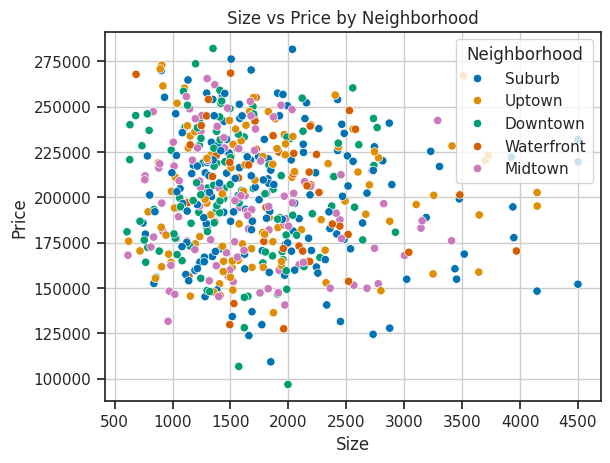

In [35]:
sns.set_theme(style = "ticks", palette = "colorblind")
sns.scatterplot(
    data = df, x = "size", y = "price", hue = "neighborhood")
plt.title("Size vs Price by Neighborhood")
if plt.gca().legend_ is not None:
    plt.gca().legend_.set_title('Neighborhood')
    plt.xlabel("Size")
plt.ylabel("Price")
plt.grid()
plt.show()

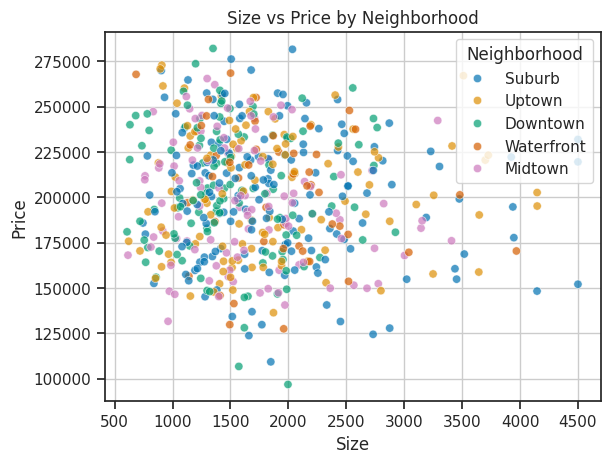

In [39]:
sns.set_theme(style = "ticks", palette = "colorblind")

sns.scatterplot(                          # alpha for transparency
    data = df, x = "size", y = "price", hue = "neighborhood", alpha = 0.7)
plt.title("Size vs Price by Neighborhood")
if plt.gca().legend_ is not None:
    plt.gca().legend_.set_title('Neighborhood')
    plt.xlabel("Size")
plt.ylabel("Price")
plt.grid()
plt.show()

### Short Answer (3--4 sentences)

-   What does seaborn automatically handle that matplotlib does not?
-   Why is transparency useful here?

Seaborn allows for more styles, such as gridlines and more color palettes.
It also provides more themes and plots distributions and better handles Pandas dataframes.  Transparency is useful for representing clusters of data by avoiding overlapping plots.

----

## B. Small Multiples (Faceting)

Create small multiples of **size vs price**, separated by `bedrooms`.

-   Keep scales consistent.
-   Add a clear overall title.

### Question

#### Does the relationship between size and price look similar across bedroom
counts?

*The relationship across bedroom counts looks similar--  
meaning there is no relationship.  
While size is correlated with the number of bedrooms, size is not correlated with price.*

------------------------------------------------------------------------


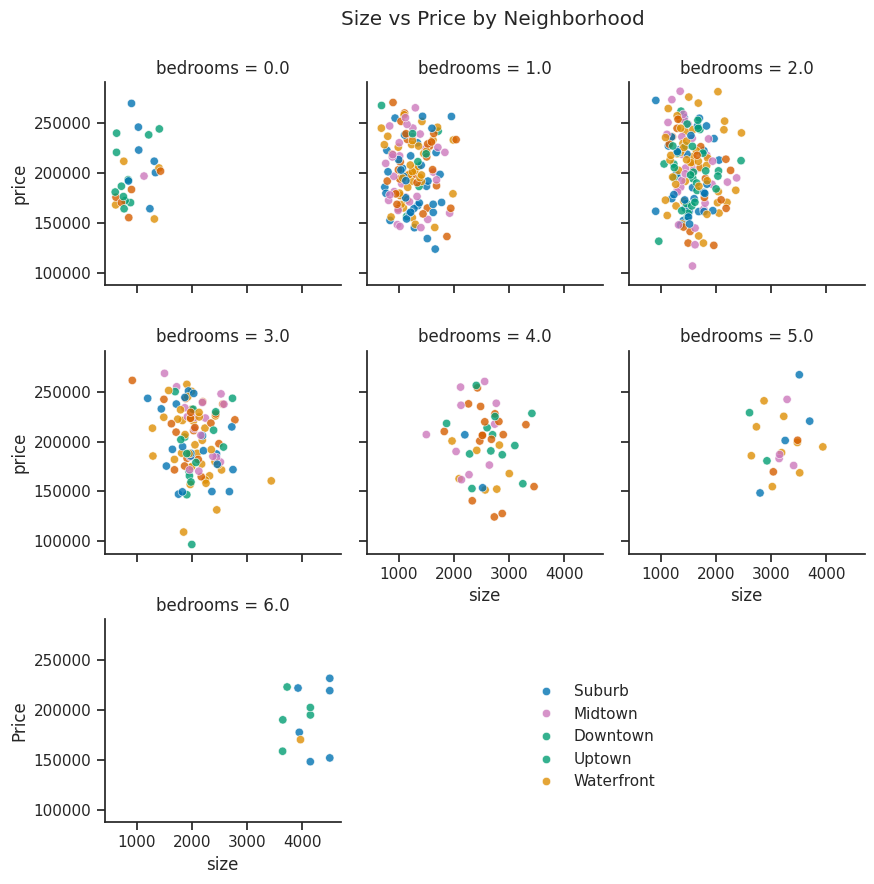

In [77]:
sns.set_theme(style = "ticks", palette = "colorblind")


df_obj = sns.FacetGrid(
    data = df,
    col = "bedrooms",
    col_wrap = 3) #must be discreet  # facet horizontally
df_obj.map_dataframe(sns.scatterplot, x = "size",
                     y = "price",
                     hue = "neighborhood", alpha = 0.8)

plt.ylabel("Price")
df_obj.fig.suptitle("Size vs Price by Neighborhood")
df_obj.fig.subplots_adjust(top=0.9)
df_obj.add_legend(loc = (0.6, 0.1))

plt.show()


## C. Distribution and Categorical Plots

1.  Create a histogram of `price`.
2.  Create a density plot of `price`.
3.  Create a boxplot of `price` by `neighborhood`.

### Interpretation (short paragraph)

-   Do neighborhoods differ systematically in price?
-   What visual evidence supports your claim?

*There is no visible difference in price by neighborhood, as evedenced by the boxplots by neighborhood.*

------------------------------------------------------------------------

<Axes: xlabel='price', ylabel='Count'>

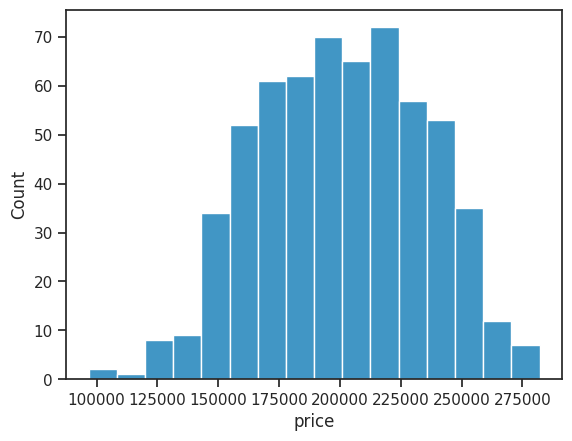

In [78]:
sns.histplot(data = df, x = "price")
plt.show()

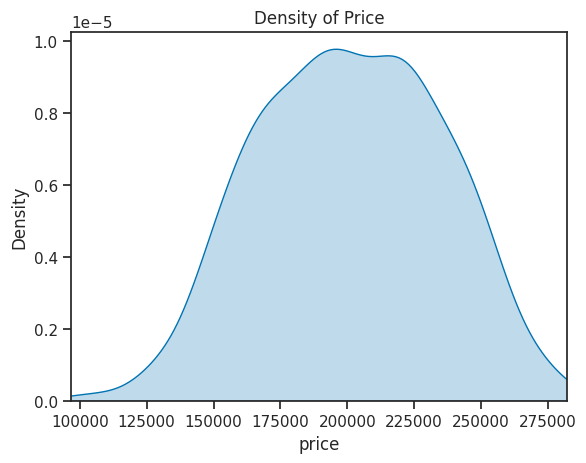

In [79]:
sns.kdeplot(data = df, x = "price", fill = True)  # normalized curve only
plt.title("Density of Price")
plt.xlim(df['price'].min(), df['price'].max())# avoid truncation: widen limits
plt.show()

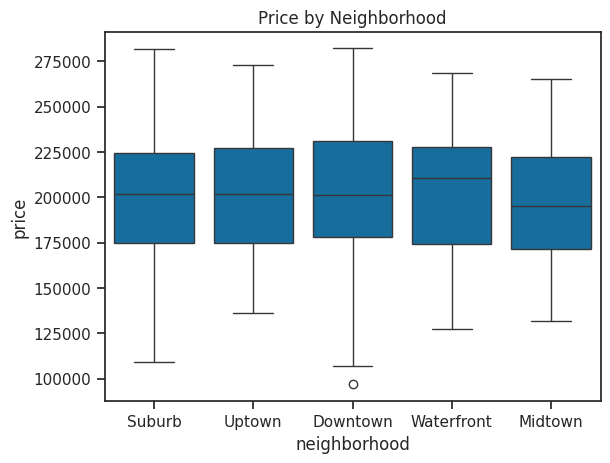

In [80]:
sns.boxplot(data = df, x = "neighborhood", y = "price")
plt.title("Price by Neighborhood")
plt.show()

###

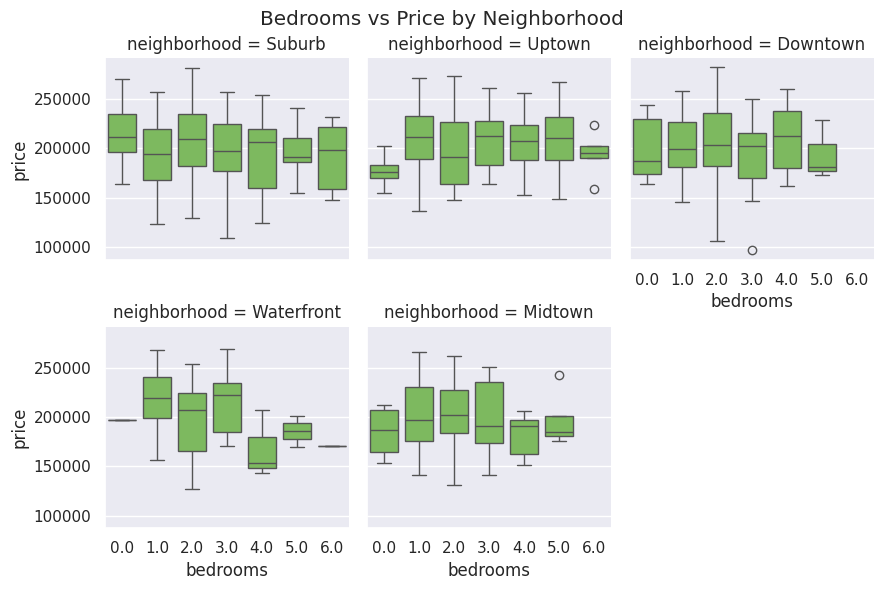

In [105]:
colors = ['#78C850']
#, '#F08030', '#6890F0','#F8D030', '#F85888', '#705898', '#98D8D8']

df_obj_2 = sns.FacetGrid(
    data = df,
    col = "neighborhood",
    col_wrap = 3)
df_obj_2.map_dataframe(sns.boxplot, x = "bedrooms",
                     y = "price",
                     hue = "neighborhood",
                    palette= colors)

plt.ylabel("Price")
df_obj_2.fig.suptitle("Bedrooms vs Price by Neighborhood")
df_obj_2.fig.subplots_adjust(top=0.9)

plt.show()

------------------------------------------------------------------------

# Part II -- Linear Regression for Inference (30 pts)

## A. Multiple Regression (R → Python)

In R, the model would be:

``` r
lm(price ~ size + bedrooms + neighborhood, data = df)
```

In Python:

1.  Fit the equivalent model using `statsmodels`.
2.  Report:
    -   Coefficient estimates
    -   Standard errors
    -   R²

------------------------------------------------------------------------
## B. Interpretation

Answer clearly:

1.  Interpret the coefficient on **size**, explicitly stating what is
    being held constant.  

    *-10.9345.  All other variables being held constant, for every square foot increase in size of the home, the price goes down by  $10.93.  
    The variables being held constant are number of bedrooms, neighborhood, and type of home.*  

2.  Is size statistically significant? How do you know?  
    
    *If alpha was set to .05 before the test is run, then the p-value of .01 shows that the test results are significant, as  
    .01 < .05*

3.  What does R² tell us in this context?  
  
    *Since the coefficient of determination (R²), is 0.017, this shows that not much of the variance is explained by the model.  R² would need to be much closer to 0 to show a strong relationship between the dependent variable to the independent variables.*

------------------------------------------------------------------------

In [107]:
# Fit a multiple linear regression using statsmodels
model_sm_multiple = smf.ols(  # Ordinary Least Squares
    "price ~ size + bedrooms + C(neighborhood)", data = df).fit()

# Display the model summary
model_sm_multiple.summary() # coefficients, SEs, t, p-values, R², etc.

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  price   R-squared:                       0.017
Model:                            OLS   Adj. R-squared:                  0.005
Method:                 Least Squares   F-statistic:                     1.460
Date:                Sun, 08 Mar 2026   Prob (F-statistic):              0.190
Time:                        21:15:04   Log-Likelihood:                -6212.8
No. Observations:                 524   AIC:                         1.244e+04
Df Residuals:                     517   BIC:                         1.247e+04
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
=================================================================================================
                                    coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------------
Intercept                      2.112e+05   4925.106     42.872      0.000    2.01e+05    2.21e+05
C(neighborhood)[T.Midtown]    -4236.1877   4809.529     -0.881      0.379   -1.37e+04    5212.435
C(neighborhood)[T.Suburb]      -562.7029   4369.989     -0.129      0.898   -9147.823    8022.417
C(neighborhood)[T.Uptown]      1311.1025   4727.959      0.277      0.782   -7977.272    1.06e+04
C(neighborhood)[T.Waterfront]  3001.3355   5984.299      0.502      0.616   -8755.198    1.48e+04
size                            -10.9345      4.210     -2.597      0.010     -19.205      -2.664
bedrooms                       4372.2643   2262.445      1.933      0.054     -72.453    8816.981
==============================================================================
Omnibus:                       12.814   Durbin-Watson:                   0.699
Prob(Omnibus):                  0.002   Jarque-Bera (JB):                7.598
Skew:                          -0.114   Prob(JB):                       0.0224
Kurtosis:                       2.456   Cond. No.                     1.05e+04
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 1.05e+04. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

------------------------------------------------------------------------

# Part III -- Prediction Workflow (20 pts)

Now switch goals: **Prediction instead of explanation**

1.  Split the data into training and test sets.
2.  Fit linear regression using `scikit-learn`.
3.  Compute:
    -   RMSE (on test set)  
        RMSE: 36867.78  

    -   R² (on test set)  
        R-squared: 0.01

------------------------------------------------------------------------

## Short Answer

-   Why does scikit-learn not report p-values?  

  `scikit-learn` *is used for prediction, while p-values are used for hypothesis-testing.*  

-   Which workflow would you use for:
    -   Explanation?  
      `statsmodels` *is used for explanation, inference, effect.*
    -   Prediction?  
     `scikit-learn` *is used for prediction.*
-   Why are these different goals?  

    `statsmodels` *is for describing the statistical relationships between variables, testing hypotheses, and estimating parameters with confidence intervals. It is used when something already occurred, and we want to explain WHY it happened.*  
      
      `scikit-learn` *is for prediction and machine learning. We use it to build models that can predict outcomes on new data (WHAT will happen).*

  
------------------------------------------------------------------------

In [109]:
# Drop rows with any NaN values from the relevant columns
df_cleaned = df.dropna(subset=["size", "bedrooms", "price"])

# Define predictors and outcome
X = df_cleaned[["size", "bedrooms"]]
y = df_cleaned["price"]

# Create train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2)

# Fit a scikit-learn linear regression model
model_sk = LinearRegression()
model_sk.fit(X_train, y_train)

# Generate predictions
y_pred = model_sk.predict(X_test)

# Compute RMSE
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print(f"RMSE: {rmse:.2f}")

# Compute R^2
r2 = r2_score(y_test, y_pred)
print(f"R-squared: {r2:.2f}")

RMSE: 36867.78
R-squared: 0.01


# Part IV -- Integrated Thinking (10 pts)

Create one polished figure that:

-   Shows size vs price
-   Colors by neighborhood
-   Includes a regression line
-   Has professional formatting

Then write 4--5 sentences:

-   Does the regression model match what you visually observed?  
      
    *The regression model shows very weak relationships, which is what I expected from the values.*


-   Did the visualization help you anticipate the model results?  

    *The model shows the plot points are greatly scattered, and not much of a pattern is visible.  
    This is what the calculations suggested.*

------------------------------------------------------------------------

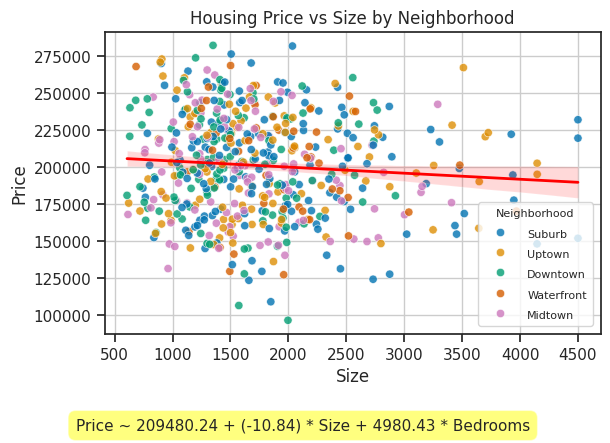

In [153]:
sns.set_theme(style = "ticks", palette = "colorblind")

# Create the scatterplot with colors by neighborhood
sns.scatterplot(
    data = df,
    x = "size",
    y = "price",
    hue = "neighborhood",
    alpha = 0.8
)

# single regression line for all points combined
sns.regplot(
    data = df,
    x = "size",
    y = "price",
    scatter = False, # Don't plot points again
    color = 'red',
    line_kws = {'linewidth': 2}
)

plt.title("Housing Price vs Size by Neighborhood")
plt.xlabel("Size")
plt.ylabel("Price")

plt.grid()

# change legend title if exists
if plt.gca().legend_ is not None:
    legend = plt.gca().legend_
    legend.set_title("Neighborhood")
    legend.get_title().set_fontsize('8') # legend title
    for text in legend.get_texts():
        text.set_fontsize('8') # font size legend labels

    # equation string format
equation_text = (
    f"Price ~ {model_sk.intercept_:.2f} + ({model_sk.coef_[0]:.2f}) * Size + {model_sk.coef_[1]:.2f} * Bedrooms")

# add equation on plot in box
# plt.text(0.05, 0.95, equation_text, transform=plt.gca().transAxes,
#          fontsize=10, verticalalignment='top',
#          bbox=dict(boxstyle='round,pad=0.5', fc='yellow', alpha=0.5))

# equation in footnote
plt.figtext(0.08, 0.05, equation_text, ha = "left", fontsize = 11,
            bbox=dict(boxstyle = 'round,pad = 0.5', fc = 'yellow', alpha = 0.5))

# stretch subplot parameters to add space at bottom
plt.subplots_adjust(bottom=0.25)

plt.show()

In [128]:
print(f"Intercept: {model_sk.intercept_:.2f}")
print(f"Coefficient for size: {model_sk.coef_[0]:.2f}")
print(f"Coefficient for bedrooms: {model_sk.coef_[1]:.2f}")


print(
    f"Price ~ {model_sk.intercept_:.2f} + {model_sk.coef_[0]:.2f} * (Size) + {model_sk.coef_[1]:.2f} * (Bedrooms)"
)

Intercept: 209480.24
Coefficient for size: -10.84
Coefficient for bedrooms: 4980.43
Price ~ 209480.24 + -10.84 * (Size) + 4980.43 * (Bedrooms)


In [ ]:
# Format the equation string
equation_text = f"Price = {intercept:.2f} + ({coef_size:.2f} * Size) + ({coef_bedrooms:.2f} * Bedrooms)"

# Add the equation to the plot (adjust x, y coordinates as needed)
plt.text(0.05, 0.95, equation_text, transform=plt.gca().transAxes, fontsize=10, verticalalignment='top', bbox=dict(boxstyle='round,pad=0.5', fc='yellow', alpha=0.5))